In [286]:
import  yfinance as yf
!pip install pmdarima
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm


In [288]:
nifty_index_data=yf.download("^NSEI",start="2024-01-01",end="2026-05-25")

[*********************100%***********************]  1 of 1 completed


In [289]:
nifty_df=nifty_index_data[['Close']].copy()
nifty_df['Daily_return']=nifty_df['Close'].pct_change()
nifty_df.dropna(inplace=True)
nifty_df.head()
nifty_df.isnull().sum()

Price         Ticker
Close         ^NSEI     0
Daily_return            0
dtype: int64

In [290]:
adf_result=adfuller(nifty_df['Daily_return'])
print(f"test statistic:{adf_result[0]:.2f}")
print(f"p value:{adf_result[1]:.3f}")

test statistic:-26.73
p value:0.000


In [291]:
from statsmodels.tsa.arima.model import ARIMA
best_aic=float('inf')
best_pqd_order=None
best_model=None

In [292]:
d=0
max_p=5
max_q=5

for p in range(max_p+1):
    for q in range(max_q+1):
        try:
            model=ARIMA(nifty_df["Daily_return"], order=(p,d,q))
            results=model.fit()
            current_aic=results.aic
            
            if current_aic<best_aic:
                best_aic=current_aic
                best_pqd_order=(p,d,q)
                best_model=results
        except:
            continue



In [293]:
print(f"best order identified with AIC: ARIMA{best_pqd_order} and AIC score: ARIMA{best_aic:.2f}")

best order identified with AIC: ARIMA(1, 0, 1) and AIC score: ARIMA-3908.83


In [294]:
print(f"number of trading days:{len(nifty_df["Daily_return"])}")

number of trading days:588


In [153]:
from sklearn.model_selection import train_test_split
train_data,test_data=train_test_split(nifty_df["Daily_return"].dropna(),
                                     test_size=0.20,
                                     shuffle=False)

train_prices_data=nifty_df["Close"].loc[train_data.index]
test_prices_data=nifty_df["Close"].loc[test_data.index]
print(f"training data :{len(train_data)} and testing data : {len(test_data)}")

training data :470 and testing data : 118


In [295]:
auto_order=pm.auto_arima(train_data,start_p=0,max_p=5,
                        start_q=0,max_q=5,
                        d=0,
                        seasonal=False,stepwise=True,
                        supress_warnings=True,
                        trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-3165.397, Time=0.23 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-3168.145, Time=0.21 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-3167.541, Time=0.28 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-3167.875, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-3167.187, Time=0.27 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-3164.327, Time=0.25 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-3167.688, Time=0.34 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 1.857 seconds


In [296]:
train_data.dropna(inplace=True)
p,d,q=1,0,0
model_fit=ARIMA(train_data, order=(p,d,q)).fit()
trading_days=30
forecast=model_fit.get_forecast(steps=trading_days)
pred_returns=forecast.predicted_mean
stnd_error=forecast.se_mean


CI_80=1.282
return_lower_80=pred_returns-CI_80*stnd_error
return_higher_80=pred_returns+CI_80*stnd_error

last_traded_price=float(train_prices_data.iloc[-1])
pred_prices=last_traded_price*(1+pred_returns).cumprod()
prices_lower_80=last_traded_price*(1+return_lower_80).cumprod()
prices_higher_80=last_traded_price*(1+return_higher_80).cumprod()

actual_pred_prices=test_prices_data.iloc[:trading_days]
forecast_dates=actual_pred_prices.index
pred_prices.index=forecast_dates
prices_lower_80.index=forecast_dates
prices_higher_80.index=forecast_dates





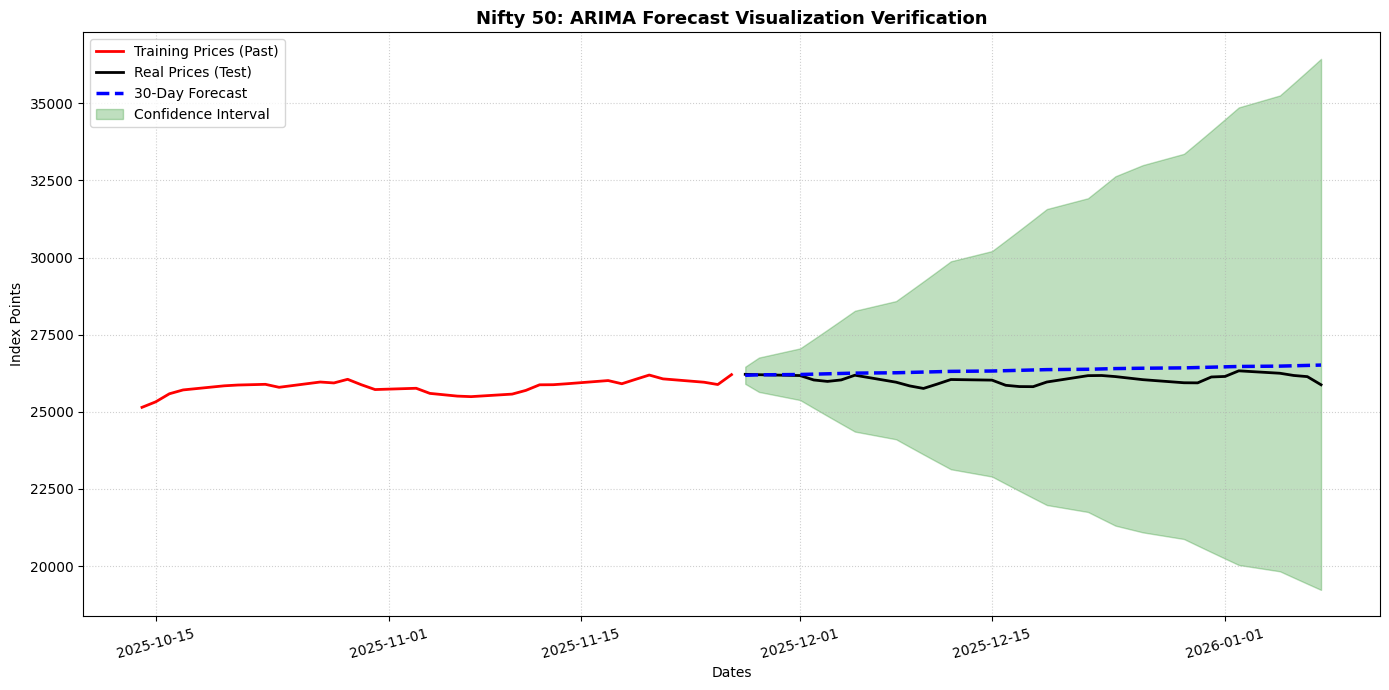

In [297]:
plt.figure(figsize=(14, 7))
plt.plot(train_prices_data.tail(30), label='Training Prices (Past)', color='red', linewidth=2)
plt.plot(actual_pred_prices, label='Real Prices (Test)', color='black', linewidth=2)
plt.plot(pred_prices, label='30-Day Forecast', color='blue', linestyle='--', linewidth=2.5)
plt.fill_between(forecast_dates, 
                 prices_lower_80, 
                 prices_higher_80, 
                 color='green', 
                 alpha=0.25, 
                 label='Confidence Interval')
plt.title('Nifty 50: ARIMA Forecast Visualization Verification', fontsize=13, fontweight='bold')
plt.xlabel('Dates')
plt.ylabel('Index Points')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [298]:
CI_95=1.96
return_lower_95=pred_returns-CI_95*stnd_error
return_higher_95=pred_returns+CI_95*stnd_error

last_traded_price=float(train_prices_data.iloc[-1])
pred_prices=last_traded_price*(1+pred_returns).cumprod()
prices_lower_95=last_traded_price*(1+return_lower_95).cumprod()
prices_higher_95=last_traded_price*(1+return_higher_95).cumprod()

actual_pred_prices=test_prices_data.iloc[:trading_days]
forecast_dates=actual_pred_prices.index
pred_prices.index=forecast_dates
prices_lower_95.index=forecast_dates
prices_higher_95.index=forecast_dates

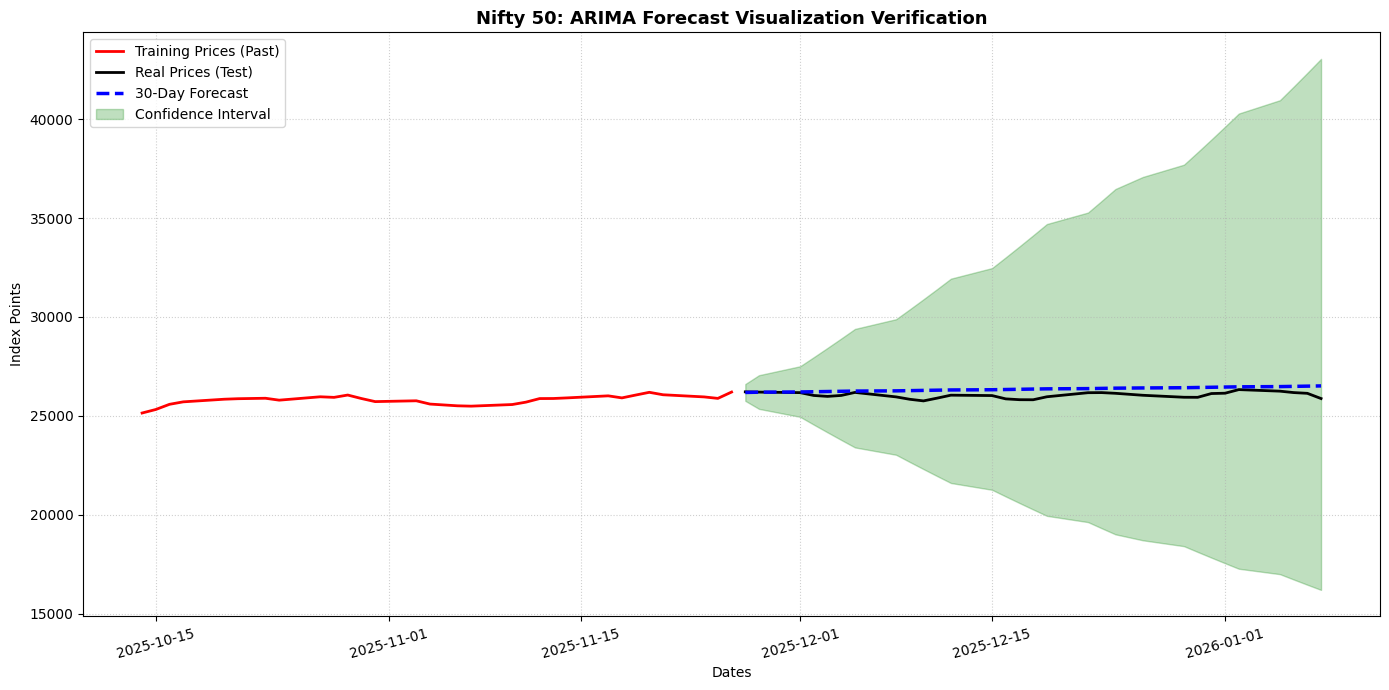

In [299]:
plt.figure(figsize=(14, 7))
plt.plot(train_prices_data.tail(30), label='Training Prices (Past)', color='red', linewidth=2)
plt.plot(actual_pred_prices, label='Real Prices (Test)', color='black', linewidth=2)
plt.plot(pred_prices, label='30-Day Forecast', color='blue', linestyle='--', linewidth=2.5)
plt.fill_between(forecast_dates, 
                 prices_lower_95, 
                 prices_higher_95, 
                 color='green', 
                 alpha=0.25, 
                 label='Confidence Interval')
plt.title('Nifty 50: ARIMA Forecast Visualization Verification', fontsize=13, fontweight='bold')
plt.xlabel('Dates')
plt.ylabel('Index Points')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [300]:
print(f"THE 30-DAY FORECAST:          ")
print(pred_prices)

THE 30-DAY FORECAST:          
Date
2025-11-27    26184.156615
2025-11-28    26198.744896
2025-12-01    26209.645459
2025-12-02    26220.932952
2025-12-03    26232.185741
2025-12-04    26243.447453
2025-12-05    26254.713576
2025-12-08    26265.984579
2025-12-09    26277.260416
2025-12-10    26288.541094
2025-12-11    26299.826615
2025-12-12    26311.116981
2025-12-15    26322.412194
2025-12-16    26333.712255
2025-12-17    26345.017168
2025-12-18    26356.326934
2025-12-19    26367.641555
2025-12-22    26378.961033
2025-12-23    26390.285371
2025-12-24    26401.614570
2025-12-26    26412.948633
2025-12-29    26424.287561
2025-12-30    26435.631357
2025-12-31    26446.980023
2026-01-01    26458.333561
2026-01-02    26469.691973
2026-01-05    26481.055261
2026-01-06    26492.423427
2026-01-07    26503.796474
2026-01-08    26515.174403
Name: predicted_mean, dtype: float64


In [301]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
predicted_prices=pred_prices.values
mse= mean_absolute_error(pred_prices,actual_pred_prices)
RMSE=np.sqrt(mse)

print(f"ROOT MEAN SQUARED ERROR: {RMSE:.2f}")

ROOT MEAN SQUARED ERROR: 17.61


In [302]:
from sklearn.metrics import mean_absolute_percentage_error
mape=mean_absolute_percentage_error(pred_prices,actual_pred_prices)
mape_percentage=mape*100
print(f"MAPE:{mape_percentage:.2f}")

MAPE:1.18
